### **👩‍🏫 👩🏿‍🏫 What You'll learn**

- Data cleaning and handling missing values
- Exploratory Data Analysis (EDA) with visualization tools like `Seaborn` and `Matplotlib`
- Feature engineering and correlation analysis
- Building and comparing regression models (Linear Regression, SVM, Decision Trees, etc.)
- Dimensionality reduction using `PCA`

---

### **🛠️ What you will create**

- A cleaned Pokemon dataset with engineered features (e.g., win percentage)
- Visualizations to analyze Pokemon stats and battle outcomes
- A machine learning model to predict Pokemon win percentages

---

### **Dataset**

**Pokemon Dataset** you can find here:

- `pokemon.csv`: Contains stats like `HP`, `Attack`, `Type 1`, `Legendary`, etc., for 800+ Pokemon.
- `combats.csv`: Records 50,000 battle outcomes between Pokemon.

### **What you need to do:**

1. **Data Preparation:**
    - Load and merge `pokemon.csv` and `combats.csv`.
    - Fix missing values:
    - Fill the missing `Name` for Pokemon #62 (Primeape).
    - Handle `NaN` values in `Type 2` (mark as "None" if missing).
    - Calculate each Pokemon's **win percentage** using the combat data.
2. **Exploratory Analysis & Visualization:**
    - Create a _correlation matrix_ to identify relationships between stats (HP, Attack, Speed) and win percentage.
    - Plot a **`Seaborn` pairplot or `PairGrid`** for stats vs. win percentage.
    - Analyze the top 10 Pokemon by win percentage and their stats.
3. **Machine Learning:**
    - Split data into training/testing sets (80/20 split).
    - Train and evaluate **3 regression models** (e.g., Linear Regression, Random Forest, XGBoost) to predict win percentage.
    - Compare model performance using **Mean Absolute Error (MAE).**


In [31]:
import os
import zipfile

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

In [4]:
zip_path = "/content/Pokemon Data Analysis Tutorial.zip"

assert os.path.exists(zip_path), (
    f"{zip_path} not found - upload the zip via the Colab file pane first."
)

In [ ]:
extract_dir = "/content/pokemon_data"

if not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

print(os.listdir(extract_dir))

['Pokemon Data Analysis Tutorial']


In [8]:
data_dir = os.path.join(extract_dir, "Pokemon Data Analysis Tutorial")

pokemon = pd.read_csv(os.path.join(data_dir, "pokemon.csv"))
combats = pd.read_csv(os.path.join(data_dir, "combats.csv"))

display(pokemon.head())

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


In [10]:
pokemon.shape

(800, 12)

In [9]:
pokemon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        799 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   HP          800 non-null    int64 
 5   Attack      800 non-null    int64 
 6   Defense     800 non-null    int64 
 7   Sp. Atk     800 non-null    int64 
 8   Sp. Def     800 non-null    int64 
 9   Speed       800 non-null    int64 
 10  Generation  800 non-null    int64 
 11  Legendary   800 non-null    bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 69.7+ KB


### Fixing Missing Values

`pokemon.info()` shows two different kinds of gap:

- `Name` is missing exactly one row (index 62 - Primeape). Will be filled manually.
- `Type 2` is missing for 386 / 800 rows (48.25%). This isn't messy data. It means the Pokemon has no second type, so it gets an explicit `None` category instead of an imputed value.


In [ ]:
pokemon.loc[pokemon["Name"].isna(), "Name"] = "Primeape"
pokemon["Type 2"] = pokemon["Type 2"].fillna("None")

pokemon.isna().sum()

,0
#,0
Name,0
Type 1,0
Type 2,0
HP,0
Attack,0
Defense,0
Sp. Atk,0
Sp. Def,0
Speed,0


In [12]:
combats.head()

,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


### Calculating Win Percentage

Win percentage = (times won as `Winner`) / (times appeared as `First_pokemon` or `Second_pokemon`)
Pokemons that never appear in `combats.csv` will be set as `NaN` rather than 0, since 0 would falsely imply they always lose instead of no data.


In [14]:
total_battles = pd.concat(
    [combats["First_pokemon"], combats["Second_pokemon"]]
).value_counts()
wins = combats["Winner"].value_counts().reindex(total_battles.index, fill_value=0)

win_pct_by_id = wins / total_battles
pokemon["win_percentage"] = pokemon["#"].map(win_pct_by_id)

pokemon["win_percentage"].isna().sum()

np.int64(16)

In [ ]:
pokemon["win_percentage"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 800 entries, 0 to 799
Series name: win_percentage
Non-Null Count  Dtype  
--------------  -----  
784 non-null    float64
dtypes: float64(1)
memory usage: 6.4 KB


### Correlation Matrix

Correlation values run from -1 to +1 with a meaningful zero midpoint (no relationship), so this uses a _diverging_ colormap (`coolwarm`) rather than a sequential one.


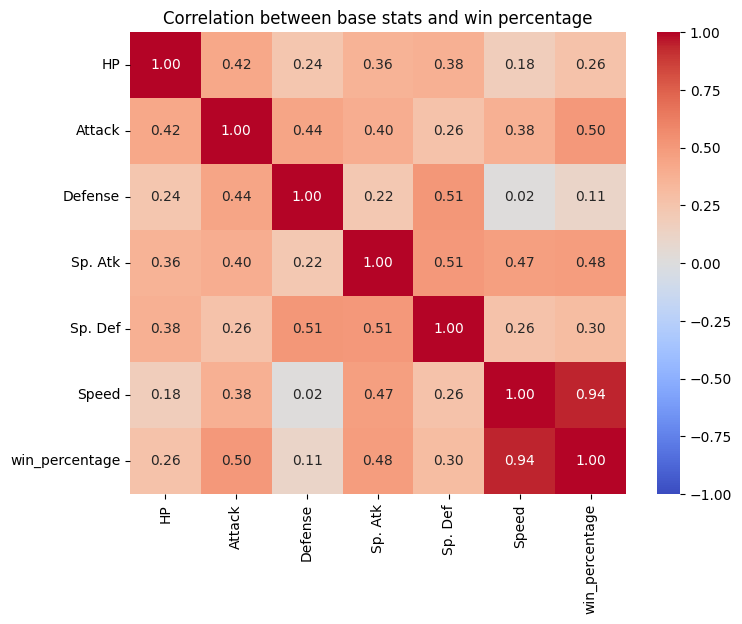

In [ ]:
stats_cols = [
    "HP",
    "Attack",
    "Defense",
    "Sp. Atk",
    "Sp. Def",
    "Speed",
    "win_percentage",
]
corr = pokemon[stats_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation between base stats and win percentage")
plt.show()

### Pairplot: stats vs. win percentage

The 16 Pokemons with no combat data (NaN win_percentage) are dropped here. A pairplot has nothing meaningful to place for them on the win_percentage axis. Colored by `Legendary` using an explicit `{False: color, True: color}` dict (not a list) passed to `palette=`, since a plain list silently mis-maps to categories under seaborn's internal hue ordering.


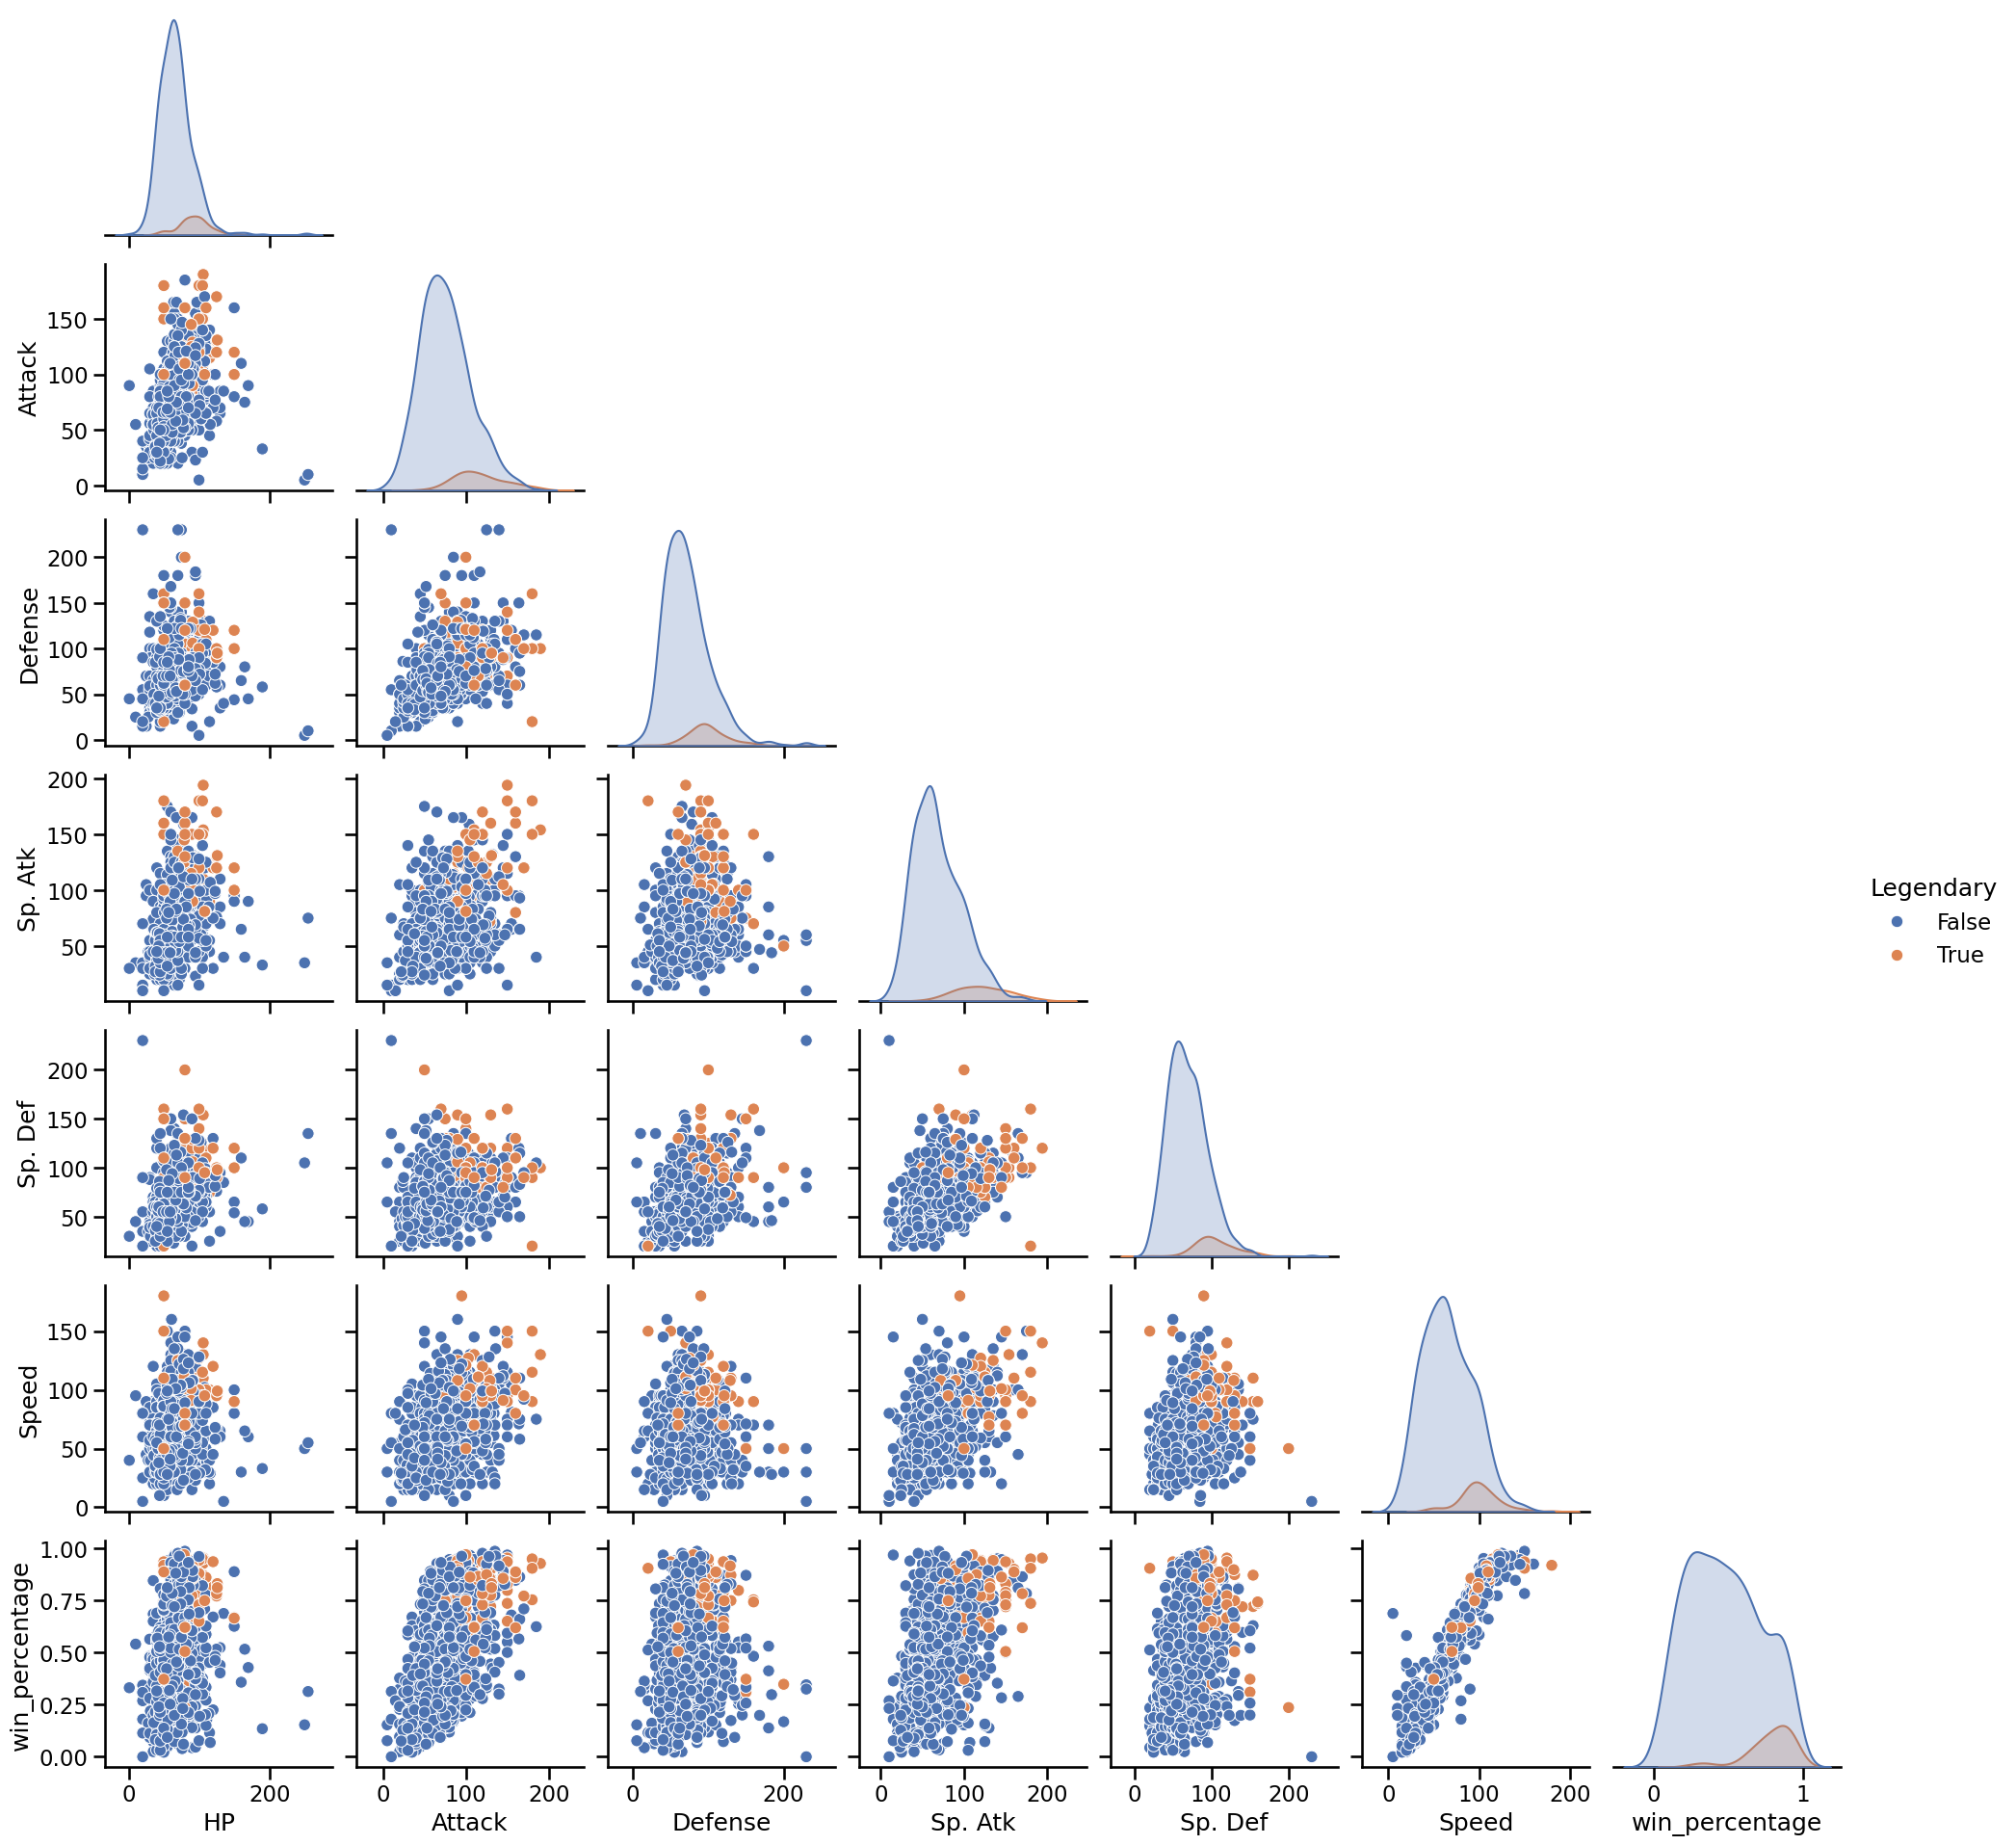

In [ ]:
sns.set_context("talk")

pair_df = pokemon[stats_cols + ["Legendary"]].dropna(subset=["win_percentage"])

legendary_palette = {False: "#4C72B0", True: "#DD8452"}

g = sns.pairplot(
    pair_df,
    vars=stats_cols,
    hue="Legendary",
    palette=legendary_palette,
    corner=True,
    height=2.8,
)
plt.show()

### Top 10 Pokemon by Win Percentage


In [26]:
top10 = pokemon.sort_values("win_percentage", ascending=False).head(10)
cols = [
    "Name",
    "Type 1",
    "Type 2",
    "HP",
    "Attack",
    "Defense",
    "Speed",
    "win_percentage",
]

top10[cols]

,Name,Type 1,Type 2,HP,Attack,Defense,Speed,win_percentage
154,Mega Aerodactyl,Rock,Flying,80,135,85,150,0.984496
512,Weavile,Dark,Ice,70,120,65,125,0.974790
703,Tornadus Therian Forme,Flying,None,79,100,80,121,0.968000
19,Mega Beedrill,Bug,Poison,65,150,40,145,0.966387
153,Aerodactyl,Rock,Flying,80,105,65,130,0.964539
476,Mega Lopunny,Normal,Fighting,65,136,94,135,0.961240
726,Greninja,Water,Dark,72,95,67,122,0.960630
716,Meloetta Pirouette Forme,Normal,Fighting,100,128,90,128,0.959350
164,Mega Mewtwo Y,Psychic,None,106,150,70,140,0.952000
349,Mega Sharpedo,Water,Dark,70,140,70,105,0.950000


In [ ]:
print("=" * 50)
print("Top 10 vs. Overall mean stats:")
print(f"{'Metric':<25} {'Top 10':<20} {'Overall':<20}")
print(
    f"{'Mean Speed:':<25} {top10['Speed'].mean():<20.2f} {pokemon['Speed'].mean():<20.2f}"
)
print(
    f"{'Mean Attack:':<25} {top10['Attack'].mean():<20.2f} {pokemon['Attack'].mean():<20.2f}"
)
print(f"{'Mean HP:':<25} {top10['HP'].mean():<20.2f} {pokemon['HP'].mean():<20.2f}")
print(
    f"{'Mean Defense:':<25} {top10['Defense'].mean():<20.2f} {pokemon['Defense'].mean():<20.2f}"
)
print("=" * 50)

print("=" * 50)
print("Top 10 vs. Overall median stats:")
print(f"{'Metric':<25} {'Top 10':<20} {'Overall':<20}")
print(
    f"{'Median Speed:':<25} {top10['Speed'].median():<20.2f} {pokemon['Speed'].median():<20.2f}"
)
print(
    f"{'Median Attack:':<25} {top10['Attack'].median():<20.2f} {pokemon['Attack'].median():<20.2f}"
)
print(
    f"{'Median HP:':<25} {top10['HP'].median():<20.2f} {pokemon['HP'].median():<20.2f}"
)
print(
    f"{'Median Defense:':<25} {top10['Defense'].median():<20.2f} {pokemon['Defense'].median():<20.2f}"
)
print("=" * 50)

Top 10 vs. Overall mean stats:
Metric                    Top 10               Overall             
Mean Speed:               130.10               68.28               
Mean Attack:              125.90               79.00               
Mean HP:                  78.70                69.26               
Mean Defense:             72.60                73.84               
Top 10 vs. Overall median stats:
Metric                    Top 10               Overall             
Median Speed:             129.00               65.00               
Median Attack:            131.50               75.00               
Median HP:                75.50                65.00               
Median Defense:           70.00                70.00               


The top 10 have a mean `Speed` of 130.10, almost double the dataset-wide mean of 68.28. This is a direct confirmation of the 0.94 correlation seen earlier.
`Defense` ranges from 40 to 94, with no clear pattern, matching its near-zero (0.11) correlation with `win_percentage`.


### Preparing Features for Modeling

The 16 Pokemons with no combat data (`Nan` `win_percentage`) are dropped, leaving 784 rows.
`Legendary` is cast from `bool` to `int` (0 / 1) since `scikit-learn` regressors need numeric input.
Features are the 6 base stats plus `Legendary`. The same variables examined in the correlation matrix and pairplot.


In [ ]:
feature_cols = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed", "Legendary"]

model_df = pokemon.dropna(subset=["win_percentage"]).copy()
model_df["Legendary"] = model_df["Legendary"].astype(int)

X = model_df[feature_cols]
y = model_df["win_percentage"]

len(model_df)

784

### Train / Test Split

An 80 / 20 split as specified in the assignment, with `random_state=42` so the split (and every model's score) is reproducible on re-runs.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

len(X_train), len(X_test)

(627, 157)

### A Shared Train / Evaluate Helper

All 3 models get fit, predict, and scored with MAE the same way, so that logic is factored into one function instead of repeating a 3-line block per model.


In [ ]:
def train_and_evaluate(
    model,
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series,
) -> float:
    """
    Fit a regression model and score it with Mean Absolute Error on the test set.

    Args:
        model: An unfitted scikit-learn regressor.
        X_train (pd.DataFrame): Training features.
        X_test (pd.DataFrame): Test features.
        y_train (pd.Series): Training target values.
        y_test (pd.Series): Test target values.

    Returns:
        float: Mean Absolute Error of the fitted model's predictions on X_test.
    """
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    return mean_absolute_error(y_test, predictions)

### Comparing 3 Regression Models

Linear Regression as a simple baseline, plus Decision Tree and Random Forest to see whether the Speed-dominant, fairly linear relationship found in the correlation matrix (0.94) actually needs tree-based nonlinearity to model well, or whether the simple baseline is already competitive.


In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
}

mae_results = {
    name: train_and_evaluate(model, X_train, X_test, y_train, y_test)
    for name, model in models.items()
}

pd.Series(mae_results).sort_values()

,0
Random Forest,0.044808
Decision Tree,0.054845
Linear Regression,0.061866


### Conclusion

This analysis set out to predict a Pokemon's win percentage from its base stats and combat history.

**Data preparation:** Of 800 Pokemon, only one had a missing name (Primeape) and 386 (48%) had
no second type. The latter isn't missing data, just single-typed Pokemon, so it was labeled
"None" rather than imputed. Win percentage was derived from 50,000 recorded battles. 16 Pokemon
never appear in `combats.csv` and were excluded from modeling for lack of data.

**EDA:** Speed is by far the strongest predictor of win percentage (0.94 correlation), while
Defense is nearly irrelevant (0.11). This held up in both the PairGrid and the top 10 Pokemon by
win percentage, who averaged 130 Speed against a dataset-wide mean of 68 - almost double.

**Modeling:** All 3 regression models learned this pattern, with Random Forest performing best
(MAE 0.045), narrowly ahead of Decision Tree (0.055) and Linear Regression (0.062). The narrow
gap between Linear Regression and the tree models suggests the underlying relationship is close
to linear, driven mostly by Speed, with only a modest nonlinear contribution from the other
stats that the tree ensemble picks up on.

**Takeaway:** if you want to guess whether a Pokemon wins a fight, look at its Speed stat first.
Almost everything else is secondary.
